In [3]:
from qiskit import QuantumCircuit
import qiskit.quantum_info as qi

In [4]:

o_b = QuantumCircuit(4)
o_b.x([0,1,2])
o_b.cx(0,3)
o_b.cx(1,3)
o_b.cx(2,3)

o_b.x([0,1,2])
o_b.draw()


┌───┐     ┌───┐          
q_0: ┤ X ├──■──┤ X ├──────────
     ├───┤  │  └───┘┌───┐     
q_1: ┤ X ├──┼────■──┤ X ├─────
     ├───┤  │    │  └───┘┌───┐
q_2: ┤ X ├──┼────┼────■──┤ X ├
     └───┘┌─┴─┐┌─┴─┐┌─┴─┐└───┘
q_3: ─────┤ X ├┤ X ├┤ X ├─────
          └───┘└───┘└───┘

In [5]:
oracle = QuantumCircuit(4)
oracle.x(3)
oracle.draw()

q_0: ─────
          
q_1: ─────
          
q_2: ─────
     ┌───┐
q_3: ┤ X ├
     └───┘

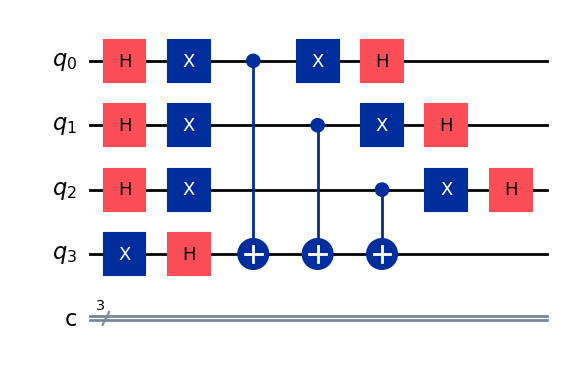

In [15]:
qc = QuantumCircuit(4, 3)

qc.x(3)
qc.h([0,1,2,3])
# qc.h(3)
qc.compose(o_b, qubits=[0,1,2,3], inplace=True)

qc.h([0,1,2])

# qc.measure([0,1,2], [0,1,2])
qc.draw(output="mpl")


In [16]:
from qiskit.quantum_info import Statevector

sv = Statevector.from_instruction(qc)
print(sv)

Statevector([ 2.07756904e-51+0.j, -6.49514367e-34+0.j, -1.22527931e-34+0.j,
              9.52420783e-18+0.j, -8.93190087e-35+0.j, -1.66988925e-17+0.j,
             -6.73463194e-18+0.j, -7.07106781e-01+0.j, -2.07756904e-51+0.j,
              6.49514367e-34+0.j,  1.22527931e-34+0.j, -9.52420783e-18+0.j,
              8.93190087e-35+0.j,  1.66988925e-17+0.j,  6.73463194e-18+0.j,
              7.07106781e-01+0.j],
            dims=(2, 2, 2, 2))


In [13]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
result = sim.run(qc, shots=1).result()
counts = result.get_counts()

print(counts)


{'111': 1}
